# Global Technology Startup Success Analysis

## Data Mining and Wrangling Assignment

**Course Code:** MTH 3102  
**Course Name:** Data Mining and Wrangling  
**Programme:** Bachelor of Science in Data Science and Analytics  
**Year:** 2  
**Semester:** 1  
**Institution:** Uganda Christian University  
**Semester:** Advent 2026  

**Name:** 
          
          BWAMBALE SEDRACK BISOGHO |
        
        
        

1. Introduction

Technology startups operate in a highly competitive and uncertain environment. While some startups grow rapidly, attract major investment, generate significant revenue, and eventually reach acquisition or public listing, others struggle financially, reduce their workforce, or eventually close.

The performance of a startup may be related to several factors, including the amount of funding it receives, its valuation, revenue generation, monthly expenditure, financial runway, workforce size, investor support, technology sector, geographical location, and adoption of artificial intelligence.

This analysis investigates a dataset of global technology startups in order to understand their characteristics and explore relationships between financial, operational, technological, and investment-related variables.



2. Dataset Source

The dataset used for this analysis is the **Global Tech Startups 2026** dataset obtained from Kaggle through the Startup Success Analysis project.

The dataset contains information about technology startups operating in different countries and technology sectors. It includes financial, geographical, operational, investment, workforce, artificial intelligence adoption, and business outcome information.

Source: Kaggle

Dataset link:
https://www.kaggle.com/code/veynvennie/startup-success-analysis/input



## 3. Motivation for Choosing the Dataset

I selected this dataset because technology startups provide an interesting setting for studying the relationship between investment, growth, financial performance, technology adoption, and business outcomes.
To explore how funding, revenue, valuation, workforce size, financial runway, investor support, AI adoption, sector, and location are associated with the performance and outcomes of technology startups


I Was  also interested in the dataset because startup growth and artificial intelligence are increasingly important areas within the technology industry. 

The dataset also contains 25,000 observations, making it sufficiently large for meaningful statistical summaries, visual comparisons, and investigation of relationships between different startup characteristics.

## 4. Research Questions

The analysis will be guided by the following questions:

1. What are the main characteristics of the startups represented in the dataset?
2. How are startup funding, valuation, revenue, burn rate, and financial runway distributed?
3. How do financial characteristics differ across funding stages?
4. Is startup funding associated with company valuation?
5. Is startup revenue associated with valuation?
6. How do financial and operational characteristics differ across startup outcomes?
7. Is AI adoption associated with startup outcomes?
8. Does investor tier appear to be associated with funding or valuation?
9. How are workforce size and layoffs related?
10. Do startup outcomes differ across technology domains or countries?
11. What important relationships exist among the numerical variables in the dataset?

In [11]:
import pandas as pd # this is our main tool. Pandas helps us to work with tables, like excel inside python.we call pd in short

import numpy as np # this helps us to do maths and calculations fast.

import matplotlib.pyplot as plt # these are usefull in visualization( drawing graphs)

import seaborn as sns   # Also help in visualization

pd.set_option("display.max_columns", None) # This just tells python to show all columns. Without it, Python hides some columns.

pd.set_option("display.float_format", lambda x: f"{x:,.2f}") # This just makes numbers look nice. instead of showing 12345.678999, it will show 12345.68 with only two decimals

In [12]:
data = pd.read_csv("global_tech_startups_2026 (1).csv") # loading the dataset
data.head() # Displays five(5) first rows
# data.tail()    displays five(5) last rows

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.80,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.20,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.10,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.70,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.00,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


In [13]:
data_raw = data.copy() # befor cleaning data better make a copy of it so for any mistake you can still have the original one.

In [14]:
print("Number of rows:", data.shape[0]) # checking the size of the dataset{0} rows
print("Number of columns:", data.shape[1]) # column

Number of rows: 25000
Number of columns: 17


In [15]:
data.shape

(25000, 17)

 Dataset Dimensions

The dataset contains **25,000 rows and 17 columns**.

Each row represents one technology startup. The columns describe different characteristics of that startup, including its technology domain, founding year, geographical location, funding stage, financial performance, workforce characteristics, investor tier, AI adoption level, and business outcome.

In [16]:
data.info() # gives full summary of the dataset

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  str    
 1   Domain                      25000 non-null  str    
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  str    
 4   City                        25000 non-null  str    
 5   Funding_Stage               25000 non-null  str    
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headcount_2026      25000 non-null

In [17]:
print("Earliest founding year:", data["Founding_Year"].min())
print("Latest founding year:", data["Founding_Year"].max())

Earliest founding year: 2012
Latest founding year: 2025


### Time Coverage

The startups represented in the dataset were founded between **2012 and 2025**. This provides several startup cohorts and allows comparisons between companies founded during different periods.

## 6. Data Cleaning and Preparation

Data cleaning was carried out systematically before the exploratory analysis. The purpose of this stage was to identify missing values, duplicated records, identifier problems, inconsistent categories, invalid numerical values, logical inconsistencies, and unusual observations.



In [18]:
data_clean = data_raw.copy()

print("Original dataset shape:", data_raw.shape)
print("Working dataset shape:", data_clean.shape)

Original dataset shape: (25000, 17)
Working dataset shape: (25000, 17)


In [19]:
missing_summary = pd.DataFrame({
    "Missing_Count": data_clean.isna().sum(),
    "Missing_Percentage": (data_clean.isna().mean() * 100).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
Company_ID,0,0.00
Domain,0,0.00
Founding_Year,0,0.00
Country,0,0.00
City,0,0.00
Funding_Stage,0,0.00
Total_Funding_USD_Millions,0,0.00
Valuation_USD_Millions,0,0.00
Revenue_ARR_Millions,0,0.00
Monthly_Burn_Rate_Millions,0,0.00


In [ ]:
data_clean.isna()# checking for missing values

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
24996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
24997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
24998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [21]:
duplicate_rows = data.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)

Number of completely duplicated rows: 0


In [22]:
print("Total rows:", len(data))
print("Unique Company IDs:", data["Company_ID"].nunique())

Total rows: 25000
Unique Company IDs: 24999


In [23]:
duplicate_ids = data[
    data["Company_ID"].duplicated(keep=False)
]

duplicate_ids

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
17524,7791E581,Generative AI,2018,Israel,Jerusalem,Seed,7.56,61.03,2.15,0.46,13.50,40,0,40,Tier 3 (Angel/Seed),NaN,Independent
23398,7791E581,HealthTech,2020,USA,New York,Seed,0.72,15.77,1.67,0.82,0.80,49,0,49,Tier 3 (Angel/Seed),Medium,Independent


Although no complete rows were duplicated, `Company_ID` was not completely unique. The identifier `7791E581` appears in two different records.

The two rows describe different startups because they differ in variables such as domain, founding year, country, city, funding, and financial characteristics.

For this reason, neither row was removed. The issue was treated as a duplicated source identifier rather than a duplicated startup observation.

In [24]:
zero_funding = data[
    data["Total_Funding_USD_Millions"] == 0
]

print(
    "Number of startups with zero funding:",
    len(zero_funding)
)

zero_funding["Investor_Tier"].value_counts()

Number of startups with zero funding: 1175


Investor_Tier
Bootstrapped    1175
Name: count, dtype: int64

Startups reporting zero total funding were investigated rather than automatically treating zero as missing data.

The zero-funded observations are associated with bootstrapped startups, which provides a logical explanation for the absence of external funding.

These zero values were therefore retained as meaningful observations.

In [25]:
data_clean.isna().sum()

Company_ID                       0
Domain                           0
Founding_Year                    0
Country                          0
City                             0
Funding_Stage                    0
Total_Funding_USD_Millions       0
Valuation_USD_Millions           0
Revenue_ARR_Millions             0
Monthly_Burn_Rate_Millions       0
Runway_Months_2024               0
Peak_Headcount_2023              0
Layoffs_2024_2025                0
Current_Headcount_2026           0
Investor_Tier                    0
AI_Adoption_Level             2592
Acquisition_Status               0
dtype: int64

In [26]:
data_clean.isna().mean() * 100

Company_ID                    0.00
Domain                        0.00
Founding_Year                 0.00
Country                       0.00
City                          0.00
Funding_Stage                 0.00
Total_Funding_USD_Millions    0.00
Valuation_USD_Millions        0.00
Revenue_ARR_Millions          0.00
Monthly_Burn_Rate_Millions    0.00
Runway_Months_2024            0.00
Peak_Headcount_2023           0.00
Layoffs_2024_2025             0.00
Current_Headcount_2026        0.00
Investor_Tier                 0.00
AI_Adoption_Level            10.37
Acquisition_Status            0.00
dtype: float64

#### Interpretation

The missing-value audit identified only one variable with incomplete data. `AI_Adoption_Level` contains **2,592 missing observations**, representing approximately **10.37% of the 25,000 startup records**.

The proportion of missing AI-adoption values is substantial enough to require further investigation. Immediately deleting all affected rows would remove more than one-tenth of the dataset, including valid financial, geographical, operational, and outcome information contained in the other variables.


In [27]:
total_missing = data_clean.isna().sum().sum()
total_cells = data_clean.shape[0] * data_clean.shape[1]

overall_missing_percentage = (
    total_missing / total_cells
) * 100

print("Total cells in dataset:", total_cells)
print("Total missing cells:", total_missing)
print(
    "Overall missing percentage:",
    round(overall_missing_percentage, 2),
    "%"
)

Total cells in dataset: 425000
Total missing cells: 2592
Overall missing percentage: 0.61 %


Although 10.37% of the `AI_Adoption_Level` variable is missing, missing values represent only approximately **0.61% of all individual cells in the entire dataset**.

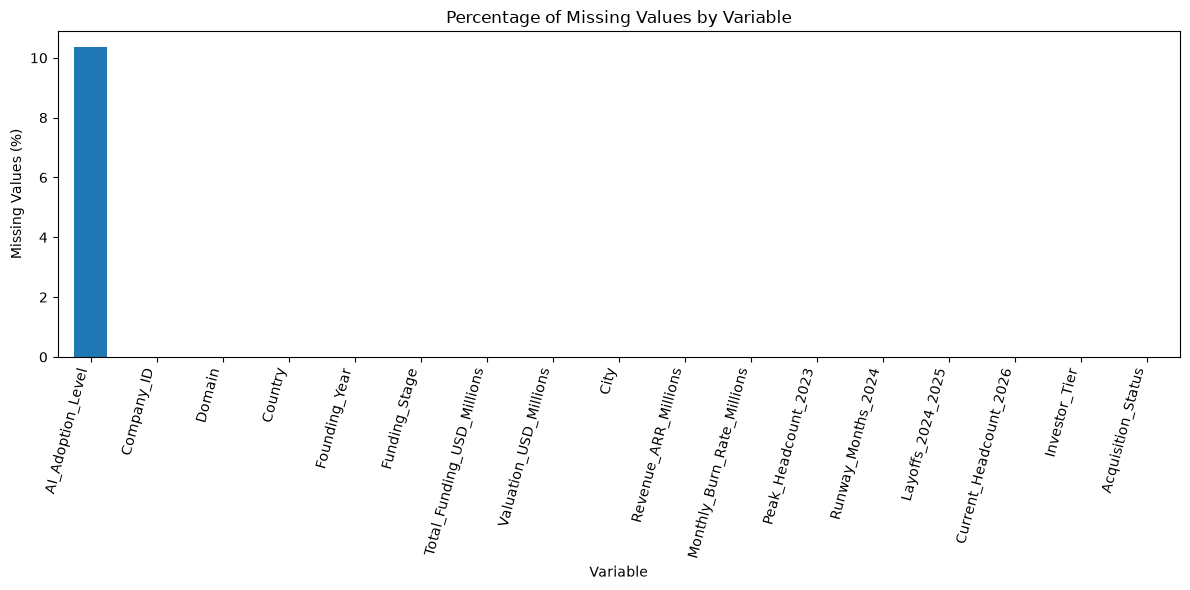

In [28]:
missing_percentages = (
    data_clean.isna().mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))

missing_percentages.plot(kind="bar")

plt.title("Percentage of Missing Values by Variable")
plt.xlabel("Variable")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

#### Missing-Value Distribution

The visualization confirms that missing data is concentrated entirely in `AI_Adoption_Level`. Approximately 10.37% of this variable is missing, while all other variables have complete observations.

Because the missingness is isolated to a single categorical variable, a targeted treatment is more appropriate than applying a general missing-value strategy to the entire dataset.

In [29]:
ai_missing = data_clean["AI_Adoption_Level"].isna()

print(ai_missing.value_counts())

AI_Adoption_Level
False    22408
True      2592
Name: count, dtype: int64


In [30]:
domain_missing = (
    data_clean.assign(AI_Missing=ai_missing)
    .groupby("Domain")["AI_Missing"]
    .agg(
        Total_Startups="count",
        Missing_AI="sum",
        Missing_Rate="mean"
    )
)

domain_missing["Missing_Rate_Pct"] = (
    domain_missing["Missing_Rate"] * 100
).round(2)

domain_missing[
    [
        "Total_Startups",
        "Missing_AI",
        "Missing_Rate_Pct"
    ]
].sort_values(
    "Missing_Rate_Pct",
    ascending=False
)

,Total_Startups,Missing_AI,Missing_Rate_Pct
Domain,,,
Web3/Crypto,2047,232,11.33
Generative AI,4958,545,10.99
HealthTech,3760,412,10.96
EdTech,1234,132,10.70
Autonomous Vehicles,1248,129,10.34
ClimateTech,2507,258,10.29
FinTech,3060,311,10.16
Cybersecurity,2466,233,9.45
SpaceTech,1252,116,9.27


#### AI Missingness by Technology Domain

The proportion of missing AI-adoption information is relatively similar across technology domains. No technology sector contains an exceptionally high or low missingness rate compared with the overall rate of 10.37%.

This provides no strong descriptive evidence that the missing AI-adoption observations are concentrated within one particular startup domain.

In [31]:
funding_missing = (
    data_clean.assign(AI_Missing=ai_missing)
    .groupby("Funding_Stage")["AI_Missing"]
    .agg(
        Total_Startups="count",
        Missing_AI="sum",
        Missing_Rate="mean"
    )
)

funding_missing["Missing_Rate_Pct"] = (
    funding_missing["Missing_Rate"] * 100
).round(2)

funding_missing[
    [
        "Total_Startups",
        "Missing_AI",
        "Missing_Rate_Pct"
    ]
].sort_values(
    "Missing_Rate_Pct",
    ascending=False
)

,Total_Startups,Missing_AI,Missing_Rate_Pct
Funding_Stage,,,
Series C+,2996,318,10.61
Seed,8859,935,10.55
Series B,5014,529,10.55
Series A,6154,628,10.20
Pre-IPO,1257,118,9.39
Post-IPO,720,64,8.89


#### AI Missingness by Funding Stage

Missing AI-adoption information is also distributed fairly evenly across funding stages. Early-stage and later-stage startups all contain some missing observations, but no stage shows a dramatically different missingness rate.

This suggests that unavailable AI-adoption information is not strongly concentrated among startups at a particular stage of financing.

In [32]:
outcome_missing = (
    data_clean.assign(AI_Missing=ai_missing)
    .groupby("Acquisition_Status")["AI_Missing"]
    .agg(
        Total_Startups="count",
        Missing_AI="sum",
        Missing_Rate="mean"
    )
)

outcome_missing["Missing_Rate_Pct"] = (
    outcome_missing["Missing_Rate"] * 100
).round(2)

outcome_missing[
    [
        "Total_Startups",
        "Missing_AI",
        "Missing_Rate_Pct"
    ]
].sort_values(
    "Missing_Rate_Pct",
    ascending=False
)

,Total_Startups,Missing_AI,Missing_Rate_Pct
Acquisition_Status,,,
Acquired (Fire Sale),1142,136,11.91
IPO,679,71,10.46
Acquired,2636,273,10.36
Independent,15456,1592,10.30
Closed,5087,520,10.22


#### AI Missingness by Startup Outcome

AI-adoption missingness is similar across startup outcomes. Closed, independent, acquired, and IPO startups all have missingness rates close to the overall 10.37% rate. Fire-sale acquisitions are slightly higher, but the difference is modest.

There is no strong descriptive evidence that missing AI-adoption information is concentrated primarily among either favourable or adverse startup outcomes.

#### Rejection of Row Deletion

Deleting every observation with missing AI-adoption information would remove **2,592 startups**, equivalent to approximately **10.37% of the dataset**.

Although AI adoption is unavailable for these records, the remaining variables contain valid financial, geographical, operational, investment, and outcome information. Removing more than one-tenth of the dataset because of a single missing categorical variable would therefore result in unnecessary information loss.

For this reason, complete-case deletion was rejected.

In [33]:
print("Before treatment:\n")

print(
    data_clean["AI_Adoption_Level"]
    .value_counts(dropna=False)
)

Before treatment:

AI_Adoption_Level
High      9814
Medium    7512
Low       5082
NaN       2592
Name: count, dtype: int64


In [34]:
data_clean["AI_Adoption_Level"] = (
    data_clean["AI_Adoption_Level"]
    .fillna("Not Reported")
)

In [35]:
data_clean["AI_Adoption_Level"] = (
    data_clean["AI_Adoption_Level"]
    .fillna("Not Reported")
)

In [36]:
print(
    "Total missing values remaining in data_clean:",
    data_clean.isna().sum().sum()
)

Total missing values remaining in data_clean: 0


#### Result of Missing-Value Treatment

The 2,592 missing `AI_Adoption_Level` observations were replaced with the explicit label `Not Reported`.

After treatment, the dataset contains no remaining null values. No startup records were deleted, so all **25,000 observations** remain available for analysis.

The treatment preserves the distinction between observed AI-adoption levels and unavailable information, avoiding unsupported imputation while maintaining the size and analytical value of the dataset.

In [37]:
missing_before = data_raw.isna().sum().sum()
missing_after = data_clean.isna().sum().sum()

missing_comparison = pd.DataFrame({
    "Dataset": ["Before Cleaning", "After AI Treatment"],
    "Total_Missing_Values": [missing_before, missing_after]
})

missing_comparison

,Dataset,Total_Missing_Values
0,Before Cleaning,2592
1,After AI Treatment,0


#### Before-and-After Comparison

Before treatment, the dataset contained 2,592 missing cells, all within `AI_Adoption_Level`. After replacing those missing observations with the explicit `Not Reported` category, the number of null values decreased to zero while the number of startup records remained unchanged.

The treatment therefore resolved the technical missing-value problem without deleting valid observations or inventing a specific AI-adoption level.

In [38]:
outlier_columns = [
    "Total_Funding_USD_Millions",
    "Valuation_USD_Millions",
    "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions",
    "Runway_Months_2024",
    "Peak_Headcount_2023",
    "Layoffs_2024_2025",
    "Current_Headcount_2026"
]

outlier_summary = []

for column in outlier_columns:

    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (
        (data[column] < lower_bound)
        | (data[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Variable": column,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2),
        "Outlier_Count": outliers
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Total_Funding_USD_Millions,2.05,36.10,34.05,-49.03,87.18,3394
1,Valuation_USD_Millions,29.00,267.79,238.80,-329.20,625.99,3445
2,Revenue_ARR_Millions,1.80,17.97,16.17,-22.46,42.23,3452
3,Monthly_Burn_Rate_Millions,0.43,2.24,1.81,-2.28,4.96,3106
4,Runway_Months_2024,3.90,17.50,13.60,-16.50,37.90,548
5,Peak_Headcount_2023,30.00,154.00,124.00,-156.00,340.00,3042
6,Layoffs_2024_2025,0.00,16.00,16.00,-24.00,40.00,3099
7,Current_Headcount_2026,22.00,119.00,97.00,-123.50,264.50,3330


The IQR method identifies several statistical outliers, particularly in financial and workforce variables.

However, these observations were not automatically removed. Technology startup datasets naturally contain large differences between small early-stage companies and very large later-stage firms. Extremely high funding, valuation, revenue, expenditure, or workforce values may therefore represent legitimate companies rather than data-entry errors.

The outliers were retained because no evidence indicated that they were invalid observations. 

## 7. Data Visualization and Exploratory Analysis

After inspecting and preparing the dataset, exploratory data analysis was carried out to understand the distributions, patterns, and important characteristics of the startups.

Different visualizations were selected depending on the type of variable being analysed. Bar charts were mainly used for categorical variables, while histograms and boxplots were used for numerical variables.



In [39]:
numerical_columns = [
    "Founding_Year",
    "Total_Funding_USD_Millions",
    "Valuation_USD_Millions",
    "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions",
    "Runway_Months_2024",
    "Peak_Headcount_2023",
    "Layoffs_2024_2025",
    "Current_Headcount_2026"
]

data_clean[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Founding_Year,"25,000.00","2,018.92",2.81,"2,012.00","2,017.00","2,019.00","2,021.00","2,025.00"
Total_Funding_USD_Millions,"25,000.00",59.63,208.73,0.00,2.05,8.46,36.10,"7,867.39"
Valuation_USD_Millions,"25,000.00",464.10,"1,777.91",1.03,29.00,71.78,267.79,"91,692.42"
Revenue_ARR_Millions,"25,000.00",33.30,139.24,0.05,1.80,4.83,17.97,"9,021.53"
Monthly_Burn_Rate_Millions,"25,000.00",3.17,10.88,0.06,0.43,0.72,2.24,515.76
Runway_Months_2024,"25,000.00",12.19,10.10,0.00,3.90,10.60,17.50,89.60
Peak_Headcount_2023,"25,000.00",211.74,693.95,5.00,30.00,48.00,154.00,"30,086.00"
Layoffs_2024_2025,"25,000.00",31.56,175.99,0.00,0.00,0.00,16.00,"10,280.00"
Current_Headcount_2026,"25,000.00",180.18,606.17,0.00,22.00,42.00,119.00,"25,657.00"


In [40]:
summary_statistics = data_clean[numerical_columns].describe().T

summary_statistics["median"] = (
    data_clean[numerical_columns].median()
)

summary_statistics = summary_statistics[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

summary_statistics

,count,mean,median,std,min,25%,50%,75%,max
Founding_Year,"25,000.00","2,018.92","2,019.00",2.81,"2,012.00","2,017.00","2,019.00","2,021.00","2,025.00"
Total_Funding_USD_Millions,"25,000.00",59.63,8.46,208.73,0.00,2.05,8.46,36.10,"7,867.39"
Valuation_USD_Millions,"25,000.00",464.10,71.78,"1,777.91",1.03,29.00,71.78,267.79,"91,692.42"
Revenue_ARR_Millions,"25,000.00",33.30,4.83,139.24,0.05,1.80,4.83,17.97,"9,021.53"
Monthly_Burn_Rate_Millions,"25,000.00",3.17,0.72,10.88,0.06,0.43,0.72,2.24,515.76
Runway_Months_2024,"25,000.00",12.19,10.60,10.10,0.00,3.90,10.60,17.50,89.60
Peak_Headcount_2023,"25,000.00",211.74,48.00,693.95,5.00,30.00,48.00,154.00,"30,086.00"
Layoffs_2024_2025,"25,000.00",31.56,0.00,175.99,0.00,0.00,0.00,16.00,"10,280.00"
Current_Headcount_2026,"25,000.00",180.18,42.00,606.17,0.00,22.00,42.00,119.00,"25,657.00"


#### Interpretation

The summary statistics reveal substantial variation among the startups, particularly in the financial variables.

For variables such as total funding, valuation, revenue, and monthly burn rate, the mean is considerably greater than the median. This indicates that these distributions are positively or right-skewed. Most startups operate at relatively smaller financial scales, while a smaller number of very large startups have extremely high values that raise the overall average.

For this reason, both the mean and median are considered during interpretation. 

### 7.2.1 Distribution of Startups by Technology Domain

The `Domain` variable identifies the main technology sector in which each startup operates. A bar chart was used to compare the number of startups across the different technology domains.

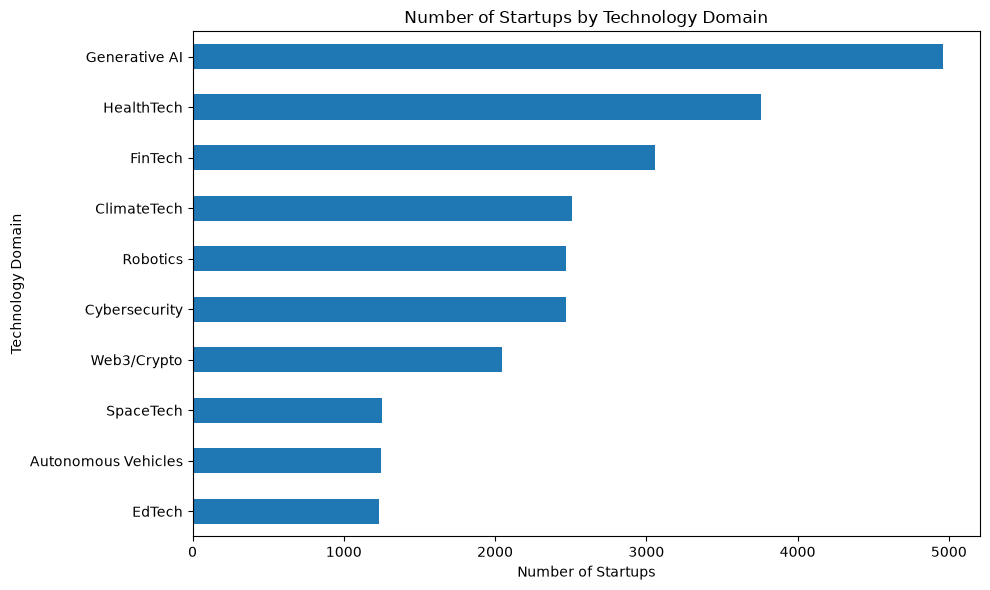

In [41]:
domain_counts = (
    data_clean["Domain"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))

domain_counts.plot(kind="barh")

plt.title("Number of Startups by Technology Domain")
plt.xlabel("Number of Startups")
plt.ylabel("Technology Domain")
plt.tight_layout()
plt.show()

In [42]:
domain_summary = pd.DataFrame({
    "Count": data_clean["Domain"].value_counts(),
    "Percentage": (
        data_clean["Domain"].value_counts(normalize=True) * 100
    ).round(2)
})

domain_summary

,Count,Percentage
Domain,,
Generative AI,4958,19.83
HealthTech,3760,15.04
FinTech,3060,12.24
ClimateTech,2507,10.03
Robotics,2468,9.87
Cybersecurity,2466,9.86
Web3/Crypto,2047,8.19
SpaceTech,1252,5.01
Autonomous Vehicles,1248,4.99


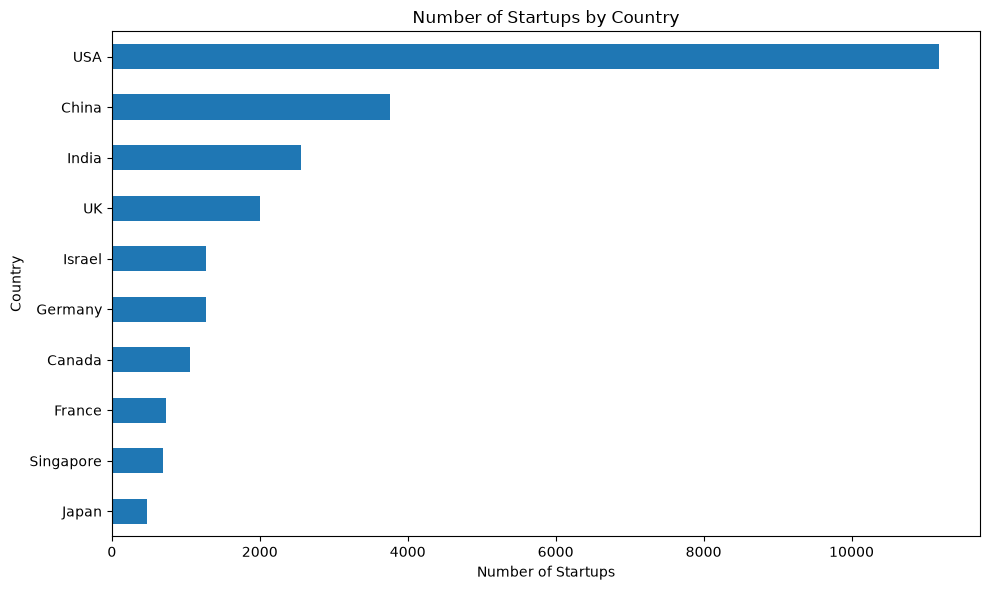

In [43]:
country_counts = (
    data_clean["Country"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))

country_counts.plot(kind="barh")

plt.title("Number of Startups by Country")
plt.xlabel("Number of Startups")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [44]:
country_summary = pd.DataFrame({
    "Count": data_clean["Country"].value_counts(),
    "Percentage": (
        data_clean["Country"].value_counts(normalize=True) * 100
    ).round(2)
})

country_summary

,Count,Percentage
Country,,
USA,11178,44.71
China,3755,15.02
India,2560,10.24
UK,1998,7.99
Israel,1277,5.11
Germany,1270,5.08
Canada,1057,4.23
France,729,2.92
Singapore,698,2.79


#### Interpretation

The geographical distribution is strongly concentrated in the United States, which accounts for the largest number of startups in the dataset. China and India form the next largest groups, while countries such as Japan, Singapore, and France contain considerably fewer observations.



### 7.2.7 Distribution of Startup Outcomes

`Acquisition_Status` records the observed business status of each startup. The categories include Independent, Closed, Acquired, Acquired (Fire Sale), and IPO.

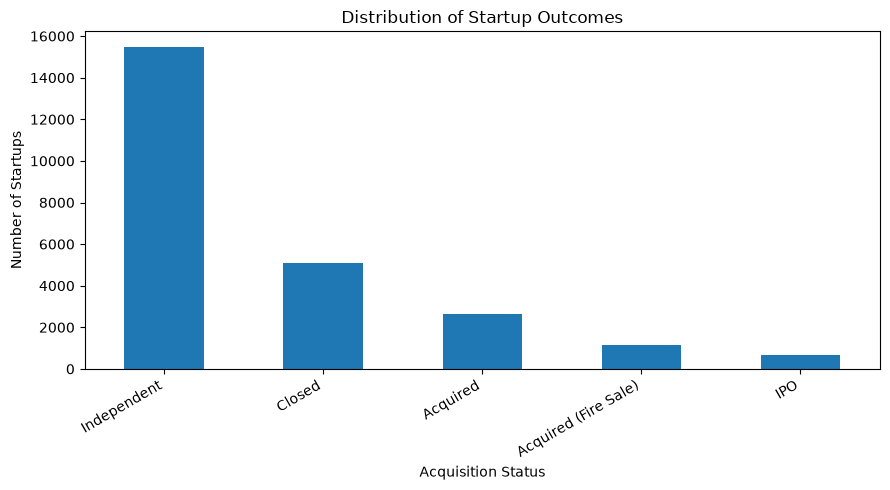

In [45]:
status_counts = (
    data_clean["Acquisition_Status"]
    .value_counts()
)

plt.figure(figsize=(9, 5))

status_counts.plot(kind="bar")

plt.title("Distribution of Startup Outcomes")
plt.xlabel("Acquisition Status")
plt.ylabel("Number of Startups")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### Interpretation

Most startups in the dataset are classified as Independent. Closed startups form the second largest outcome group, followed by Acquired companies. IPOs and fire-sale acquisitions are comparatively uncommon.



### 7.3 Startup Founding Years

The number of startups founded in each year was examined to understand the age structure of the dataset. Because year is an ordered variable, the observations were arranged chronologically.

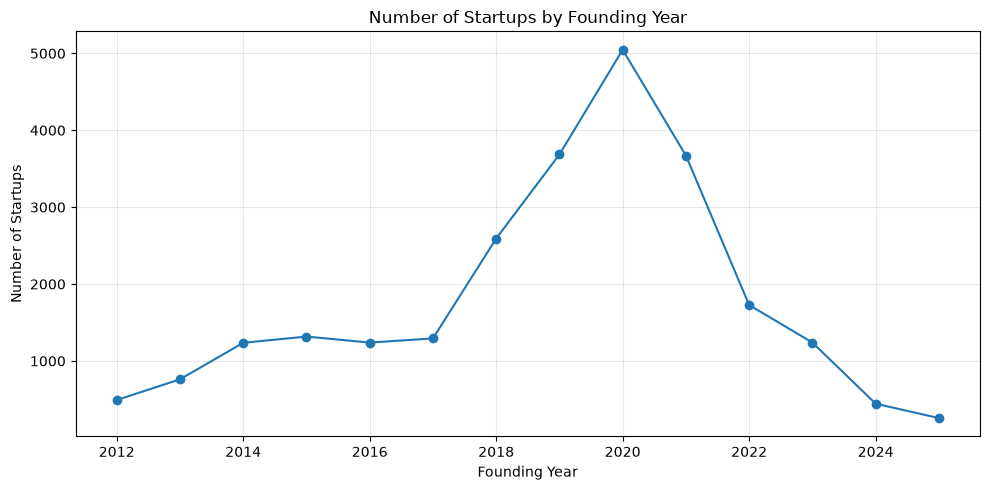

In [46]:
founding_counts = (
    data_clean["Founding_Year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

founding_counts.plot(
    kind="line",
    marker="o"
)

plt.title("Number of Startups by Founding Year")
plt.xlabel("Founding Year")
plt.ylabel("Number of Startups")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation

The number of startups represented in the dataset varies considerably across founding years. Startup representation increases across several earlier cohorts and is particularly high around 2020, while the most recent founding years contain fewer observations.

Startups founded close to 2025 have had less time to develop, raise funding, or become represented in later-stage startup data. 

### 7.4 Distribution of Numerical Variables

The numerical variables were examined using histograms and boxplots. Histograms show how observations are distributed across different values, while boxplots help identify the median, spread, and unusually large or small observations.



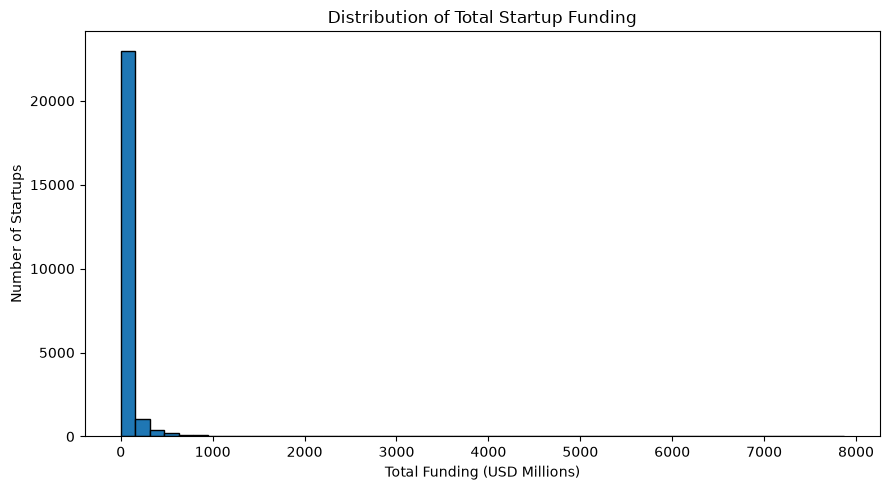

In [47]:
plt.figure(figsize=(9, 5))

plt.hist(
    data_clean["Total_Funding_USD_Millions"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Total Startup Funding")
plt.xlabel("Total Funding (USD Millions)")
plt.ylabel("Number of Startups")
plt.tight_layout()
plt.show()

C:\Users\Bienvenue\AppData\Local\Temp\ipykernel_14544\3705915413.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


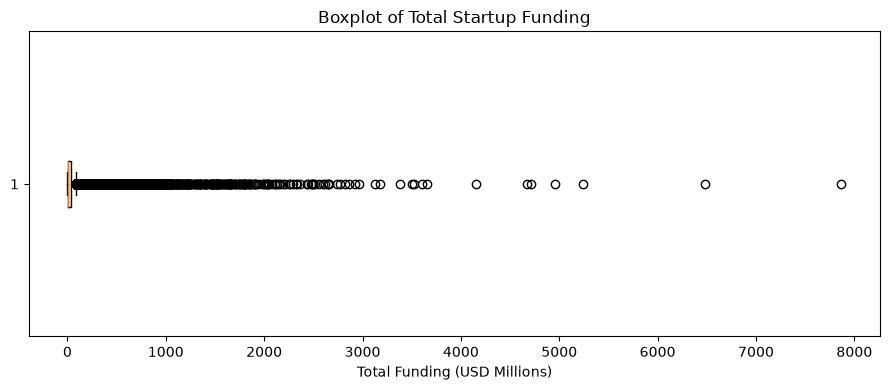

In [48]:
plt.figure(figsize=(9, 4))

plt.boxplot(
    data_clean["Total_Funding_USD_Millions"],
    vert=False
)

plt.title("Boxplot of Total Startup Funding")
plt.xlabel("Total Funding (USD Millions)")
plt.tight_layout()
plt.show()

##### Interpretation

Total startup funding is strongly right-skewed. Most startups have raised relatively modest amounts of capital, while a much smaller number have received exceptionally large investments.

The mean funding amount is considerably higher than the median. This difference occurs because the largest funding observations pull the  average upward. 

#### 7.4.3 Annual Recurring Revenue

Annual recurring revenue (ARR) measures the recurring revenue generated by each startup over a year, expressed in millions of US dollars. 

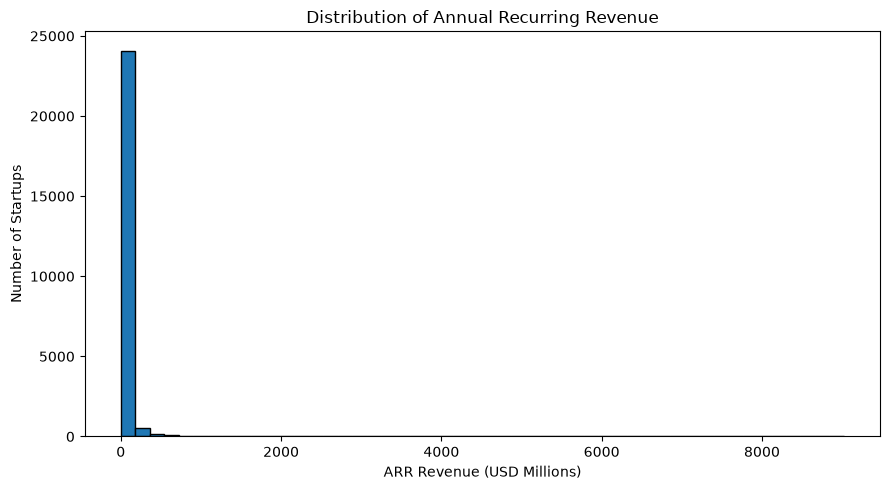

In [49]:
plt.figure(figsize=(9, 5))

plt.hist(
    data_clean["Revenue_ARR_Millions"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Annual Recurring Revenue")
plt.xlabel("ARR Revenue (USD Millions)")
plt.ylabel("Number of Startups")
plt.tight_layout()
plt.show()

##### Interpretation

Annual recurring revenue is also strongly right-skewed. Most startups generate relatively modest recurring revenue compared with a small group of very large companies.

The mean revenue is substantially greater than the median, demonstrating that a small number of high-revenue startups have a strong influence on the average.



## 8. Relationships Between Numerical Variables

This section investigates selected relationships between important financial variables in the startup dataset.

Scatterplots are used because both variables in each comparison are numerical. Pearson correlation coefficients are also calculated to measure the strength and direction of the linear relationships.

A correlation coefficient ranges from -1 to +1:

- values close to +1 indicate a strong positive relationship;
- values close to -1 indicate a strong negative relationship;
- values close to 0 indicate little or no linear relationship.



### 8.1 Total Funding and Startup Valuation

The relationship between total funding and startup valuation was investigated to determine whether startups that raise larger amounts of capital also tend to have higher estimated company valuations.

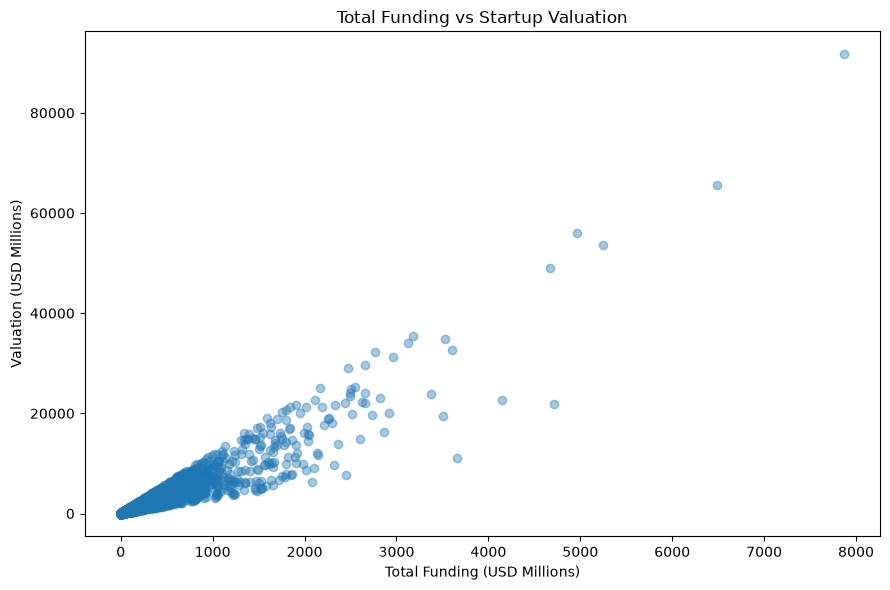

In [50]:
plt.figure(figsize=(9, 6))

plt.scatter(
    data_clean["Total_Funding_USD_Millions"],
    data_clean["Valuation_USD_Millions"],
    alpha=0.4
)

plt.title("Total Funding vs Startup Valuation")
plt.xlabel("Total Funding (USD Millions)")
plt.ylabel("Valuation (USD Millions)")
plt.tight_layout()
plt.show()

In [51]:
funding_valuation_corr = data_clean[
    "Total_Funding_USD_Millions"
].corr(
    data_clean["Valuation_USD_Millions"]
)

print(
    "Correlation between Total Funding and Valuation:",
    round(funding_valuation_corr, 3)
)

Correlation between Total Funding and Valuation: 0.945


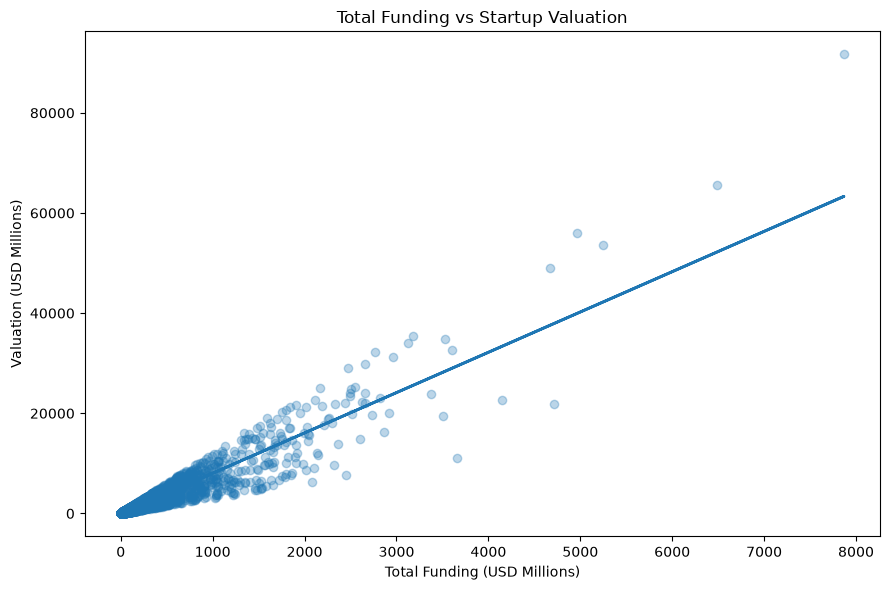

In [52]:
x = data["Total_Funding_USD_Millions"]
y = data["Valuation_USD_Millions"]

plt.figure(figsize=(9, 6))

plt.scatter(
    x,
    y,
    alpha=0.3
)

# Calculate line of best fit
m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linewidth=2
)

plt.title("Total Funding vs Startup Valuation")
plt.xlabel("Total Funding (USD Millions)")
plt.ylabel("Valuation (USD Millions)")
plt.tight_layout()
plt.show()

The fitted line further highlights the strong upward relationship between funding and valuation. Although individual startups vary around the line, the general pattern shows that higher funding levels are associated with higher company valuations.

#### Interpretation

The scatterplot shows a clear positive relationship between total funding and startup valuation. Startups that have raised larger amounts of funding generally also have higher valuations.

The Pearson correlation coefficient is approximately **0.945**, indicating a very strong positive linear relationship between the two variables.

This relationship does not prove that additional funding directly causes a startup's valuation to increase. Funding and valuation may both be influenced by other factors such as company size, growth, revenue, investor confidence, and funding stage.

### 8.2 Annual Recurring Revenue and Startup Valuation

The relationship between annual recurring revenue and startup valuation was examined to determine whether startups generating greater recurring revenue also tend to have higher estimated valuations.

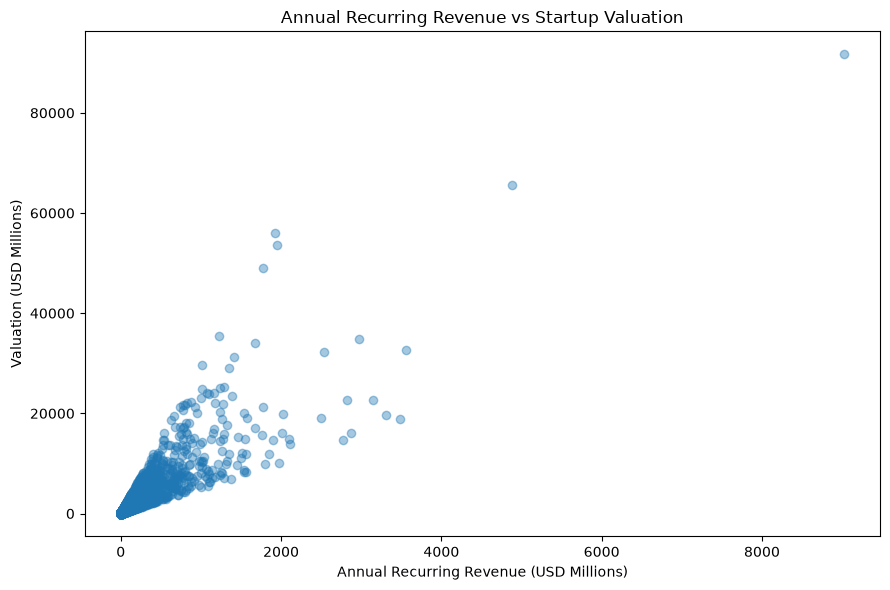

In [53]:
plt.figure(figsize=(9, 6))

plt.scatter(
    data_clean["Revenue_ARR_Millions"],
    data_clean["Valuation_USD_Millions"],
    alpha=0.4
)

plt.title("Annual Recurring Revenue vs Startup Valuation")
plt.xlabel("Annual Recurring Revenue (USD Millions)")
plt.ylabel("Valuation (USD Millions)")
plt.tight_layout()
plt.show()

In [54]:
revenue_valuation_corr = data_clean[
    "Revenue_ARR_Millions"
].corr(
    data_clean["Valuation_USD_Millions"]
)

print(
    "Correlation between Revenue and Valuation:",
    round(revenue_valuation_corr, 3)
)

Correlation between Revenue and Valuation: 0.885


#### Interpretation

The scatterplot indicates a strong positive relationship between annual recurring revenue and startup valuation. Startups generating higher recurring revenue generally tend to have higher valuations.

The Pearson correlation coefficient is approximately **0.885**, which indicates a very strong positive linear relationship.

This result is reasonable in the startup context because revenue generation provides evidence of business activity and market demand and may contribute to how investors value a company.


### 8.3 Total Funding and Annual Recurring Revenue

The relationship between total funding and annual recurring revenue was examined to determine whether startups that have raised more investment also tend to generate greater recurring revenue.

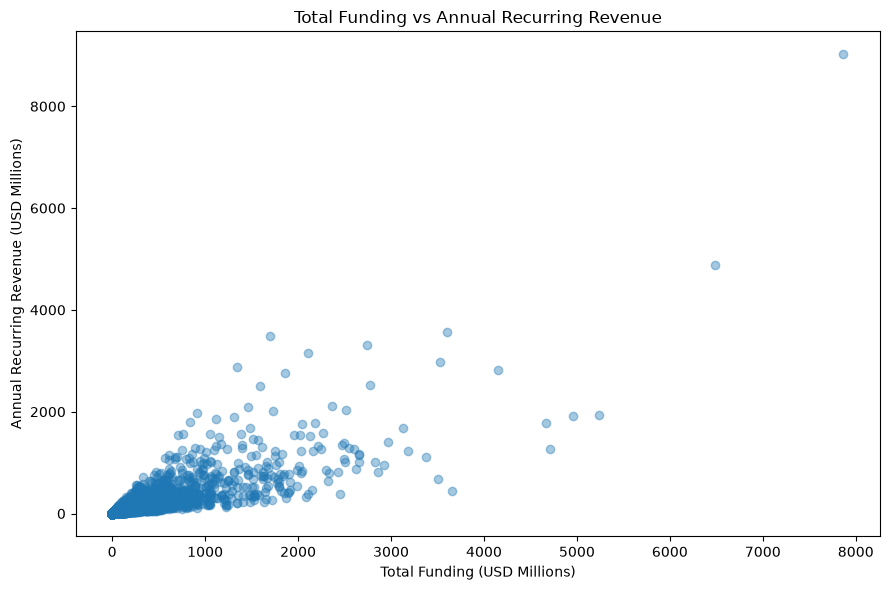

In [55]:
plt.figure(figsize=(9, 6))

plt.scatter(
    data_clean["Total_Funding_USD_Millions"],
    data_clean["Revenue_ARR_Millions"],
    alpha=0.4
)

plt.title("Total Funding vs Annual Recurring Revenue")
plt.xlabel("Total Funding (USD Millions)")
plt.ylabel("Annual Recurring Revenue (USD Millions)")
plt.tight_layout()
plt.show()

In [56]:
funding_revenue_corr = data_clean[
    "Total_Funding_USD_Millions"
].corr(
    data_clean["Revenue_ARR_Millions"]
)

print(
    "Correlation between Total Funding and Revenue:",
    round(funding_revenue_corr, 3)
)

Correlation between Total Funding and Revenue: 0.839


#### Interpretation

The scatterplot shows a positive relationship between total funding and annual recurring revenue. Startups that have raised more capital generally tend to generate greater recurring revenue.

The Pearson correlation coefficient is approximately **0.839**, indicating a strong positive linear relationship.

However, this relationship is slightly weaker than the relationships between funding and valuation and between revenue and valuation.

The result does not mean that receiving more funding automatically causes greater revenue. More mature startups may simultaneously have greater funding, larger customer bases, higher revenue, and more advanced funding stages.

In [57]:
financial_variables = data[
    [
        "Total_Funding_USD_Millions",
        "Valuation_USD_Millions",
        "Revenue_ARR_Millions"
    ]
]

correlation_matrix = financial_variables.corr()

correlation_matrix

,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions
Total_Funding_USD_Millions,1.00,0.95,0.84
Valuation_USD_Millions,0.95,1.00,0.88
Revenue_ARR_Millions,0.84,0.88,1.00


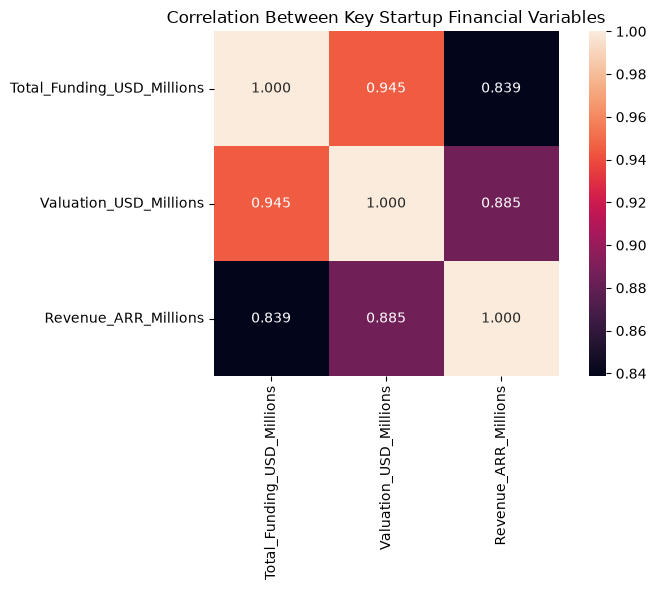

In [58]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    square=True
)

plt.title("Correlation Between Key Startup Financial Variables")
plt.tight_layout()
plt.show()

### 8.4 Summary of Financial Relationships

All three financial relationships are positive and strong.

The strongest relationship is between **total funding and valuation**, with a correlation of approximately **0.945**. This is followed by the relationship between **revenue and valuation**, with a correlation of approximately **0.885**.

The relationship between **funding and revenue** is also strong, with a correlation of approximately **0.839**, although it is the weakest of the three comparisons.

Overall, the results suggest that larger startups tend to raise more capital, generate more recurring revenue, and achieve higher valuations. These financial measures appear closely related within the dataset, but the analysis demonstrates association rather than causation.

### Correlation Heatmap of Numerical Variables

A correlation heatmap was created to examine the strength and direction of linear relationships among the numerical variables in the dataset.

Correlation coefficients range from **-1 to +1**. Values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, while values close to 0 indicate a weak linear relationship.

The heatmap provides an overall view of the numerical relationships before individual relationships are interpreted in greater detail.

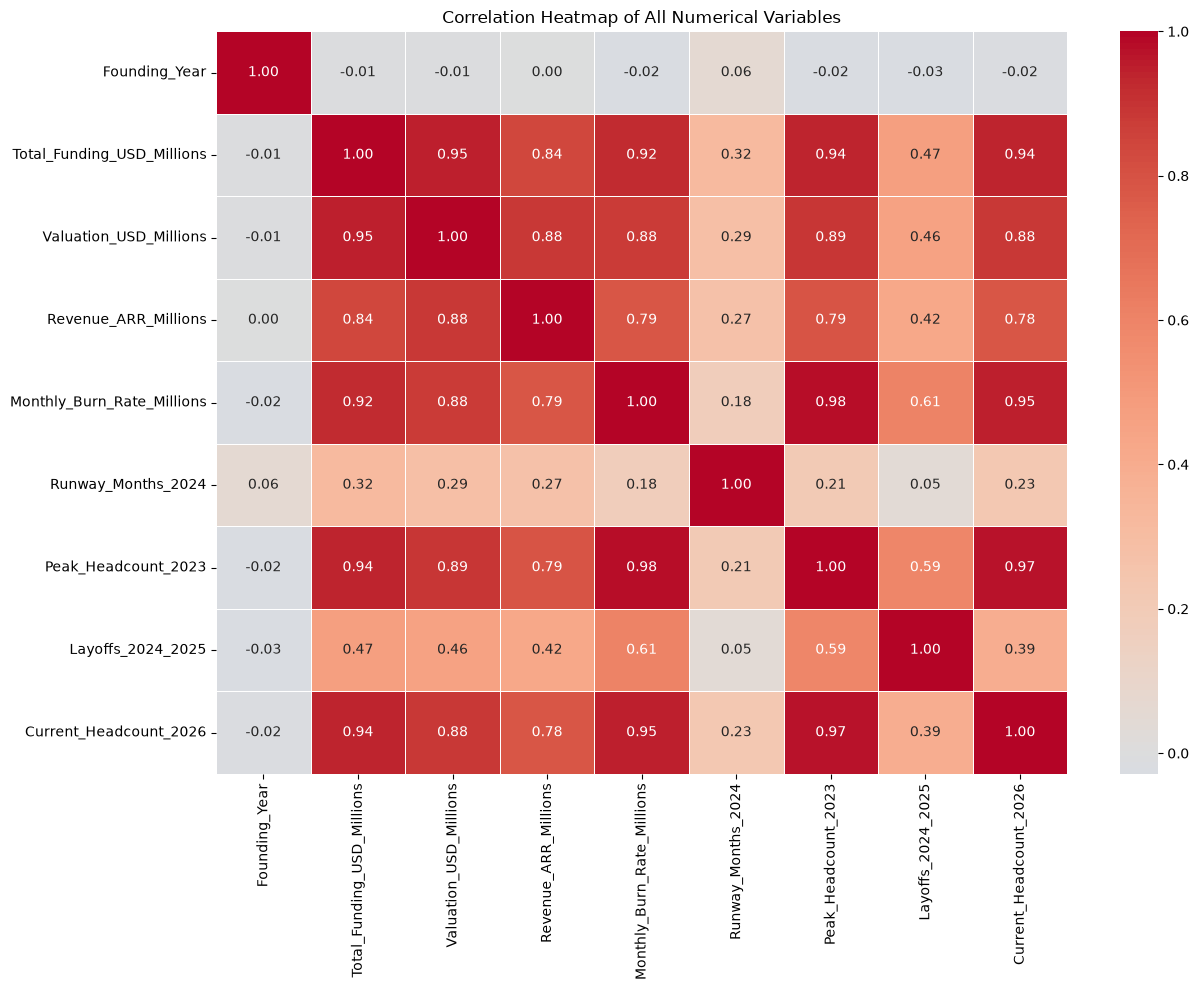

In [59]:

# Select all numerical variables
numerical_data = data.select_dtypes(include="number")

# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()

# Create the heatmap
plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of All Numerical Variables")
plt.tight_layout()
plt.show()

#### Interpretation

The correlation heatmap reveals several important relationships among the numerical variables.

The strongest financial relationship is between total funding and startup valuation. These variables have a very strong positive correlation, indicating that startups with greater funding generally also have higher valuations.

Revenue also has a strong positive relationship with valuation, while total funding and revenue are strongly positively related. These results support the earlier scatterplot analysis and show that the main measures of startup financial scale tend to increase together.

Several strong relationships also appear among the workforce variables. These should be interpreted carefully because `Current_Headcount_2026` is mathematically calculated from peak headcount and layoffs. Therefore, the strong correlations among these variables do not represent completely independent relationships.

Similarly, `Startup_Age_2026` has a perfect negative relationship with `Founding_Year` because startup age was directly calculated as 2026 minus the founding year.



## 9. Major Findings

The exploratory analysis of the global technology startup dataset produced several important findings:

1. The dataset contains 25,000 startup observations covering a wide range of technology sectors, geographical locations, funding stages, financial characteristics, and business outcomes.

2. Generative AI is the most represented technology domain, followed by HealthTech and FinTech, showing a strong representation of emerging technology industries within the dataset.

3. The United States contains the largest share of startups in the dataset, with substantially more observations than any other country. This unequal geographical representation should be considered when interpreting country-level patterns.

4. Most startups are found at the earlier funding stages. Seed-stage companies form the largest group, while Pre-IPO and Post-IPO companies are comparatively uncommon.

5. Funding, valuation, annual recurring revenue, monthly burn rate, and workforce size are strongly right-skewed. Most startups operate at relatively modest financial and operational scales, while a small number of very large companies produce extremely high values.

6. Because of this skewness, the median often provides a more representative description of a typical startup than the mean.

7. Most startups reported no layoffs during 2024–2025, although a smaller number experienced substantial workforce reductions.

8. AI adoption is commonly reported as High or Medium among startups with available AI-adoption information. The 2,592 originally missing AI-adoption observations were retained as `Not Reported` rather than being deleted or assigned an unsupported adoption level.

9. Total funding and startup valuation have a very strong positive relationship, with a Pearson correlation of approximately 0.945.

10. Annual recurring revenue and valuation also have a very strong positive relationship, with a correlation of approximately 0.885.

11. Total funding and annual recurring revenue have a strong positive relationship, with a correlation of approximately 0.839.

12. Overall, larger startups in the dataset tend to raise more capital, generate more recurring revenue, and achieve higher valuations. However, these relationships represent associations and should not be interpreted as proof of causation.

## 12. References

Kaggle. *Global Tech Startups 2026 / Startup Success Analysis*.  
https://www.kaggle.com/code/veynvennie/startup-success-analysis/input

In [60]:
print("Final number of rows:", data_clean.shape[0])
print("Final number of columns:", data_clean.shape[1])
print("Remaining missing values:", data_clean.isna().sum().sum())
print("Complete duplicated rows:", data_clean.duplicated().sum())

Final number of rows: 25000
Final number of columns: 17
Remaining missing values: 0
Complete duplicated rows: 0
